<!-- Cell 1 -->
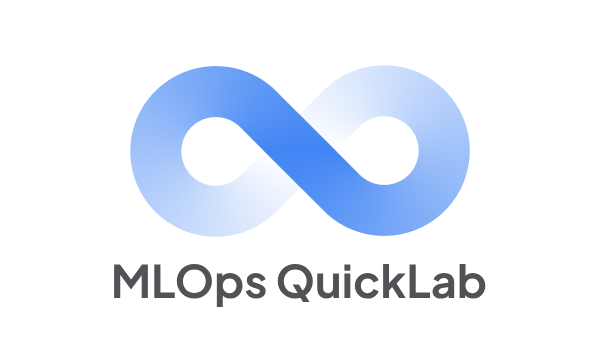

7. Vertex AI - 빅데이터를 이용한 모델 학습 및 배포

In [1]:
# Cell 2
import warnings
warnings.filterwarnings("ignore")  # suppress CUDA capability warning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import random
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

# 한글 폰트 설정 (로컬)
_font_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "NotoSansCJK-Regular.ttc")
if os.path.exists(_font_path):
    fm.fontManager.addfont(_font_path)
    plt.rcParams["font.family"] = "Noto Sans CJK JP"
    print("Korean font loaded")


Korean font loaded


``<!-- Cell 3 -->
## Kaggle 인증 설정 (최초 1회)

1. [https://www.kaggle.com/settings](https://www.kaggle.com/settings) → **API** → **Create New Token** 클릭 → `kaggle.json` 다운로드
2. 터미널에서 아래 명령 실행:

```bash
mkdir -p ~/.kaggle && cp ~/Downloads/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
```

> `kaggle.json`이 이미 `~/.kaggle/` 에 있으면 아래 Cell 3을 그냥 실행하면 됩니다.


In [2]:
# Cell 4
# Kaggle 인증 (로컬 환경)
# ~/.kaggle/kaggle.json 파일이 있으면 자동으로 인증됩니다.
# 없을 경우: https://www.kaggle.com/settings → API → "Create New Token" 후 다운로드
# 터미널에서: mkdir -p ~/.kaggle && cp ~/Downloads/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# 직접 환경변수 입력이 필요한 경우 아래 주석 해제:
# os.environ["KAGGLE_USERNAME"] = "your_kaggle_username"
# os.environ["KAGGLE_KEY"] = "your_kaggle_api_key"

kaggle_json = os.path.expanduser("~/.kaggle/kaggle.json")
if os.path.exists(kaggle_json):
    print("Kaggle credentials found:", kaggle_json)
else:
    print("WARNING: ~/.kaggle/kaggle.json not found. Kaggle download will fail.")


Kaggle credentials found: /home/changilkim/.kaggle/kaggle.json


<!-- Cell 5 -->
## Kaggle로 부터 데이터셋 준비
https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data 데이터셋 활용
위 데이터셋은 유저 `Cust_Id`의 영화 `Movie_Id` 시청에 따른 호응도 `Rating` 정보가 포함되어있음.

**데이터 형태**

Item | Description
-----|-------------
특징 | 시계열 데이터 (Time series)
전체 크기 | 100 ,480,507
영화 수 | 17,770

In [3]:
# Cell 6
import os

!pip install kaggle -q

if not os.path.exists("netflix-prize-data/combined_data_1.txt"):
    !kaggle datasets download -d netflix-inc/netflix-prize-data
    !unzip -o "netflix-prize-data.zip" -d netflix-prize-data
else:
    print("Data already exists, skipping download.")


Data already exists, skipping download.


In [4]:
# Cell 7
!head netflix-prize-data/combined_data_1.txt

1:
1488844,3,2005-09-06
822109,5,2005-05-13
885013,4,2005-10-19
30878,4,2005-12-26
823519,3,2004-05-03
893988,3,2005-11-17
124105,4,2004-08-05
1248029,3,2004-04-22
1842128,4,2004-05-09


In [5]:
# Cell 8
!ls -alh netflix-prize-data | grep combined_data

-rw-rw-r-- 1 changilkim changilkim 473M Nov 13  2019 combined_data_1.txt
-rw-rw-r-- 1 changilkim changilkim 530M Nov 13  2019 combined_data_2.txt
-rw-rw-r-- 1 changilkim changilkim 444M Nov 13  2019 combined_data_3.txt
-rw-rw-r-- 1 changilkim changilkim 527M Nov 13  2019 combined_data_4.txt


<!-- Cell 9 -->
## 데이터 전처리

1억개 전체 데이터로 학습을 돌리면, 매 Epoch당 약 6시간의 학습 시간이 요구되어
Epoch 당 약 10분의 학습 시간을 유도하기 위해 User 기준으로 `1 / 30` Ratio 비중으로 샘플링 수행.

In [6]:
# Cell 10
def load_netflix_data(data_dir: str) -> pd.DataFrame:
    files = [
        os.path.join(data_dir, f)
        for f in [
            "combined_data_1.txt",
            "combined_data_2.txt",
            "combined_data_3.txt",
            "combined_data_4.txt",
        ]
    ]
    data = pd.DataFrame()

    for file in files:
        df = pd.read_csv(file, header=None, names=["Cust_Id", "Rating", "Date"], usecols=[0, 1, 2])
        df["Rating"] = df["Rating"].astype(float)
        df["Movie_Id"] = (
            df["Cust_Id"]
            .apply(lambda x: x[:-1] if ":" in x else np.nan)
            .ffill()
            .astype(int)
        )
        df = df[df["Rating"].notna()]
        data = pd.concat([data, df])

    sample_fraction = 1 / 30.0
    sampled_users = random.sample(data["Cust_Id"].unique().tolist(),
                                    int(len(data["Cust_Id"].unique()) * sample_fraction))
    sampled_data = data[data["Cust_Id"].isin(sampled_users)]

    return sampled_data

<!-- Cell 11 -->
## 모델 정의
모델은 `Rating`을 GT(Ground Truth) 데이터로 사용하여 예측하는 문제.

In [7]:
# Cell 12
import warnings
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


Using device: cuda
GPU: NVIDIA GB10
VRAM: 121.7 GB


In [8]:
# Cell 13
from typing import Tuple
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class NetflixDataset(Dataset):
    def __init__(self, data: pd.DataFrame, seq_len: int = 10):
        """
        data: Cust_Id, Movie_Id, Rating, Date 등의 열을 가진 DataFrame
        seq_len: 시퀀스 길이
        """
        self.seq_len = seq_len
        # 유저별 데이터 그룹핑 후 시퀀스 생성
        self.data = data.groupby("Cust_Id").apply(self._create_sequences).reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.data)

    def _create_sequences(self, user_data: pd.DataFrame) -> pd.DataFrame:
        # 날짜 기준으로 정렬
        user_data = user_data.sort_values(by="Date")

        # i:i+seq_len 윈도우로 Movie_Id, Rating을 시퀀스로 구성
        sequences = [
            (
                user_data["Movie_Id"].values[i:i+self.seq_len],
                user_data["Rating"].values[i:i+self.seq_len],
            )
            for i in range(len(user_data) - self.seq_len + 1)  # seq_len 길이를 만족하는 마지막 인덱스까지
        ]

        return pd.DataFrame(sequences, columns=["Movie_Sequence", "Rating_Sequence"])

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        movies = torch.tensor(self.data.iloc[idx]["Movie_Sequence"], dtype=torch.long)
        ratings = torch.tensor(self.data.iloc[idx]["Rating_Sequence"], dtype=torch.float)

        return movies, ratings

In [9]:
# Cell 14
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, max_len: int = 5000):
        super(SinusoidalPositionalEncoding, self).__init__()
        # pos: [0 ... max_len-1]
        position = torch.arange(max_len).unsqueeze(1)
        # div_term: 각 차원별 주기를 달리하기 위한 분모
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

        # pos_embedding: (max_len, emb_size)
        pos_embedding = torch.zeros(max_len, emb_size)
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        pos_embedding[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pos_embedding', pos_embedding)  # 학습 X, 등록된 텐서

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, emb_size)
        seq_len = x.size(1)
        # pos_embedding 중 seq_len 길이에 해당하는 부분만 사용
        return x + self.pos_embedding[:seq_len, :]

class RecommendationNetwork(nn.Module):
    def __init__(
        self,
        num_movies: int,
        emb_size: int = 100,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 512,
        max_seq_len: int = 5000  # 가변 시퀀스 길이 지원을 위해 충분히 큰 값 설정
    ):
        super(RecommendationNetwork, self).__init__()

        self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
        self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_size, 1)

    def forward(self, movies: torch.Tensor) -> torch.Tensor:
        """
        movies: (batch_size, seq_len)
        seq_len이 가변적이어도 positional encoding을 매번 해당 길이에 맞춰 계산 가능
        """
        batch_size, seq_len = movies.size()

        embedded = self.movie_emb(movies)  # (batch_size, seq_len, emb_size)
        pos_encoded = self.pos_encoder(embedded)  # (batch_size, seq_len, emb_size)

        transformer_out = self.transformer_encoder(pos_encoded)  # (batch_size, seq_len, emb_size)
        preds = self.fc(transformer_out[:, -1, :])  # (batch_size, 1)

        return preds.squeeze(1)  # (batch_size,)

In [10]:
# Cell 15
# 로컬 실행 시 노트북과 같은 디렉터리에 netflix-prize-data 폴더가 있어야 합니다
NOTEBOOK_DIR = os.getcwd()  # PyCharm에서는 working directory = 프로젝트 루트
data_dir = os.path.join(NOTEBOOK_DIR, "netflix-prize-data")
print(f"Data directory: {data_dir}")

# Load data
data = load_netflix_data(data_dir)
print(f"Loaded {len(data):,} records")


Data directory: /home/changilkim/Documents/aiffel_class/MLOps06/netflix-prize-data
Loaded 3,365,130 records


In [11]:
# Cell 16
# Process data
dataset = NetflixDataset(data)
data_loader = DataLoader(dataset, batch_size=512, shuffle=True)

In [12]:
# Cell 17
num_movies = data["Movie_Id"].max()
model = RecommendationNetwork(num_movies=num_movies, emb_size=100).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
# Cell 18
def calculate_accuracy(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    # 평점을 반올림하여 정확도 계산 (정수 평점 가정)
    y_pred_rounded = torch.round(y_pred)
    correct_predictions = (y_pred_rounded == y_true).float().sum()
    accuracy = correct_predictions / y_true.shape[0]
    return accuracy.item()

In [14]:
# Cell 19
loss_values: list[float] = []
accuracy_values: list[float] = []
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_accuracy = 0.0
    count_batches = 0

    for movies, ratings in tqdm(data_loader):
        movies = movies.to(device)     # (batch_size, seq_len)
        ratings = ratings.to(device)   # (batch_size, seq_len)

        # 마지막 영화에 대한 평점 예측을 목표로 한다고 가정
        target = ratings[:, -1]  # 시퀀스의 마지막 평점을 타겟으로
        optimizer.zero_grad()
        outputs = model(movies)  # (batch_size,)

        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        accuracy = calculate_accuracy(outputs, target)
        total_loss += loss.item()
        total_accuracy += accuracy
        count_batches += 1

    avg_loss = total_loss / count_batches
    avg_accuracy = total_accuracy / count_batches
    loss_values.append(avg_loss)
    accuracy_values.append(avg_accuracy)
    print(f"Epoch {epoch+1}: Loss = {avg_loss}, Accuracy = {avg_accuracy}")

100%|██████████| 6296/6296 [01:56<00:00, 54.17it/s]


Epoch 1: Loss = 1.0593604856801457, Accuracy = 0.3608729558153104


100%|██████████| 6296/6296 [01:48<00:00, 58.00it/s]


Epoch 2: Loss = 1.0065026278151945, Accuracy = 0.3720962084460592


100%|██████████| 6296/6296 [01:52<00:00, 55.98it/s]


Epoch 3: Loss = 0.9837716406322495, Accuracy = 0.3771418465876519


100%|██████████| 6296/6296 [01:56<00:00, 53.99it/s]


Epoch 4: Loss = 0.9687962014952336, Accuracy = 0.380403236984222


100%|██████████| 6296/6296 [02:00<00:00, 52.23it/s]

Epoch 5: Loss = 0.9561665496650463, Accuracy = 0.3831778351723996


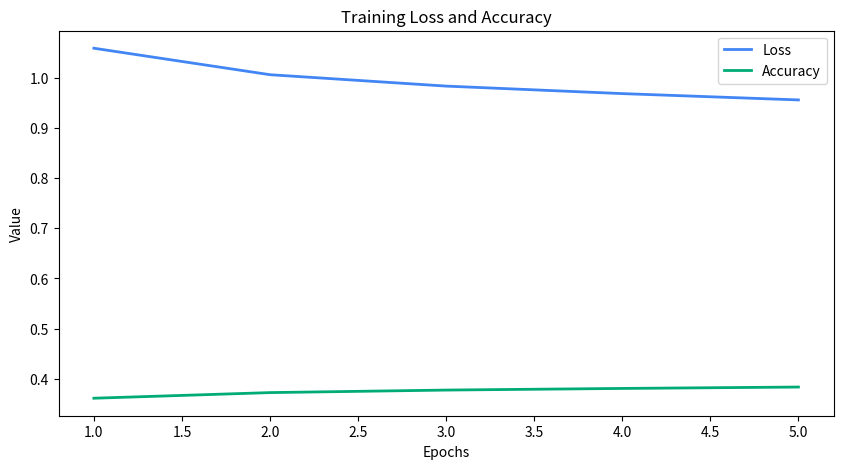

In [15]:
# Cell 20
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), loss_values, label="Loss", color="#4285f4", linewidth=2)
plt.plot(range(1, num_epochs+1), accuracy_values, label="Accuracy", color="#00ab75", linewidth=2)
plt.title("Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.show()

<!-- Cell 21 -->
## Inference

In [16]:

%%writefile model.py
#Cell 21
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, max_len: int = 5000):
        super(SinusoidalPositionalEncoding, self).__init__()
        # pos: [0 ... max_len-1]
        position = torch.arange(max_len).unsqueeze(1)
        # div_term: 각 차원별 주기를 달리하기 위한 분모
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

        # pos_embedding: (max_len, emb_size)
        pos_embedding = torch.zeros(max_len, emb_size)
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        pos_embedding[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pos_embedding', pos_embedding)  # 학습 X, 등록된 텐서

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, emb_size)
        seq_len = x.size(1)
        # pos_embedding 중 seq_len 길이에 해당하는 부분만 사용
        return x + self.pos_embedding[:seq_len, :]

class RecommendationNetwork(nn.Module):
    def __init__(
        self,
        num_movies: int,
        emb_size: int = 100,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 512,
        max_seq_len: int = 5000  # 가변 시퀀스 길이 지원을 위해 충분히 큰 값 설정
    ):
        super(RecommendationNetwork, self).__init__()

        self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
        self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_size, 1)

    def forward(self, movies: torch.Tensor) -> torch.Tensor:
        """
        movies: (batch_size, seq_len)
        seq_len이 가변적이어도 positional encoding을 매번 해당 길이에 맞춰 계산 가능
        """
        batch_size, seq_len = movies.size()

        embedded = self.movie_emb(movies)  # (batch_size, seq_len, emb_size)
        pos_encoded = self.pos_encoder(embedded)  # (batch_size, seq_len, emb_size)

        transformer_out = self.transformer_encoder(pos_encoded)  # (batch_size, seq_len, emb_size)
        preds = self.fc(transformer_out[:, -1, :])  # (batch_size, 1)

        return preds.squeeze(1)  # (batch_size,)

Overwriting model.py


In [17]:

%%writefile handler.py
# Cell 23
import logging
from ts.torch_handler.base_handler import BaseHandler
import torch
from model import RecommendationNetwork

logging.basicConfig(level=logging.INFO)

class NetflixRecommendation(BaseHandler):
    def initialize(self, context):
        properties = context.system_properties
        model_dir = properties.get("model_dir")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.num_movies = 17770
        # 가변 길이를 지원하는 모델이므로 seq_len을 고정하지 않습니다.
        self.model = RecommendationNetwork(num_movies=self.num_movies, emb_size=100)
        model_path = model_dir + "/model.pth"
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.to(self.device)
        self.model.eval()

    def preprocess(self, data):
        """
        data 예: [[{"movies": [m1, ..., mN]}], [{"movies": [...]}, ...]]
        """
        logging.info("preprocess input: %s", data)

        # 요청 구조 기록
        self.batch_structure = [len(batch) for batch in data]

        sequences = []
        for batch in data:
            for row in batch:
                movie_seq = row["movies"]
                # 가변 길이 시퀀스를 지원하므로, 길이 검사를 제거합니다.
                sequences.append(movie_seq)

        # 패딩 필요 여부에 따라 처리할 수 있습니다.
        # Transformer에 바로 넣으려면 패딩과 마스크 처리 필요.
        # 여기서는 단순히 텐서 변환(가장 긴 시퀀스에 맞춰 패딩 필요)
        # 예: padding 처리
        max_len = max(len(seq) for seq in sequences)
        padded_sequences = [seq + [0]*(max_len - len(seq)) for seq in sequences]

        movies_tensor = torch.tensor(padded_sequences, dtype=torch.long, device=self.device)
        self.max_len = max_len  # postprocessing할 때는 필요없지만, inference에서 사용할 수 있음

        return movies_tensor

    def inference(self, data):
        """
        data: (total_batch_size, max_seq_len) 텐서 (패딩된 형태)
        """
        logging.info("inference data shape: %s", data.shape)
        with torch.no_grad():
            outputs = self.model(data)  # (total_batch_size,) 형태
        return outputs.tolist()

    def postprocess(self, inference_output):
        """
        inference_output: flat list of predictions
        """
        logging.info("postprocess output: %s", inference_output)

        final_output = []
        idx = 0
        for size in self.batch_structure:
            batch_preds = inference_output[idx:idx+size]
            idx += size
            final_output.append(batch_preds)
        return final_output

Overwriting handler.py


In [18]:
# Cell 24
torch.save(model.state_dict(), "model.pth")

In [19]:
# Cell 25
# 가상의 Context 클래스 정의 (TorchServe context 모사)
class Context:
    def __init__(self):
        self.system_properties = {
            "model_dir": "."
        }


context = Context()

In [20]:
# Cell 26
!pip install torchserve torch-model-archiver

In [21]:
# Cell 27
from handler import NetflixRecommendation

# 핸들러 인스턴스화 및 초기화
netflix_recommendation = NetflixRecommendation()
netflix_recommendation.initialize(Context())

# 샘플 입력: seq_len=10 짜리 영화 시퀀스
sample_input = {"movies": [123, 456, 789, 100, 101, 102, 103, 104, 105, 106]}

# TorchServe 표준 입력 형태: [[sample_input]]
preprocessed = netflix_recommendation.preprocess([[sample_input]])
predicted_rating = netflix_recommendation.inference(preprocessed)
result = netflix_recommendation.postprocess(predicted_rating)

print(f"Predicted Rating: {result}")

OpenVINO is not enabled
proceeding without onnxruntime
Torch TensorRT not enabled
INFO:root:preprocess input: [[{'movies': [123, 456, 789, 100, 101, 102, 103, 104, 105, 106]}]]
INFO:root:inference data shape: torch.Size([1, 10])
INFO:root:postprocess output: [4.2613444328308105]


Predicted Rating: [[4.2613444328308105]]


<!-- Cell 28 -->
## Register to Vertex AI

In [22]:
# Cell 29
!torch-model-archiver \
    --model-name model \
    --version 1.0 \
    --model-file model.py \
    --serialized-file model.pth \
    --handler handler.py \
    --export-path . \
    --force

WARNING - Overwriting ./model.mar ...


In [23]:

%%writefile config.properties
# Cell 30
inference_address=http://0.0.0.0:9080
management_address=http://0.0.0.0:9081
metrics_address=http://0.0.0.0:9082
disable_system_metrics=true
number_of_netty_threads=32
job_queue_size=1000
model_store=/home/model-server/model-store

Overwriting config.properties


In [24]:
# Cell 31
# # for testing
# !torchserve \
#     --start \
#     --model-store ./ \
#     --models recommendation=model.mar \
#     --ts-config config.properties

# curl http://localhost:9080/ping

In [25]:
# Cell 32
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
!pip install google-cloud-storage google-cloud-aiplatform google-auth -q

from google.cloud import storage, aiplatform
from google.oauth2 import service_account


In [26]:
# Cell 33
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
# from google.colab import auth
# auth.authenticate_user()

In [27]:
# Cell 34
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
import os

# Safe defaults — downstream cells check these even if bucket-init cell is skipped
credentials = None
bucket = None

CREDENTIALS_FILE = (
    "moonlit-dynamo-492711-n6-39ee9b54e920.json"
    if os.path.exists("moonlit-dynamo-492711-n6-39ee9b54e920.json")
    else "credentials.json"
)

if os.path.exists(CREDENTIALS_FILE):
    credentials = service_account.Credentials.from_service_account_file(CREDENTIALS_FILE)
    print(f"GCP credentials loaded: {CREDENTIALS_FILE}")
else:
    print("WARNING: credentials file not found. GCP/Vertex AI cells will be skipped.")


GCP credentials loaded: moonlit-dynamo-492711-n6-39ee9b54e920.json


In [28]:
# Cell 35
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
PROJECT_ID = "moonlit-dynamo-492711-n6"                    # @param {type: "string"}
LOCATION = "asia-northeast3"                                       # @param {type: "string"}
BUCKET_NAME = "mlops-quicklab-1"   # @param {type: "string"}
MODEL_FILE_NAME = "model.mar"              # @param {type: "string"}

In [29]:
# Cell 36
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
if credentials:
    storage_client = storage.Client(credentials=credentials)
    bucket = storage_client.bucket(BUCKET_NAME)
    print(f"Bucket {BUCKET_NAME} ready.")
else:
    bucket = None
    print("Skipped: no GCP credentials.")


Bucket mlops-quicklab-1 ready.


In [30]:
# Cell 37
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
def upload_blob(source_file_name: str, destination_blob_name: str) -> None:
    if bucket is None:
        print("Skipped: bucket not initialized.")
        return
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")


In [44]:
# Cell 38
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
if credentials:
    upload_blob("model.mar", f"models/{MODEL_FILE_NAME}")
    upload_blob("model.pth", "models/model.pth")
    print("All model files uploaded to GCS.")
else:
    print('Skipped: no GCP credentials.')


File model.mar uploaded to models/model.mar.
File model.pth uploaded to models/model.pth.
All model files uploaded to GCS.


In [32]:
# Cell 39
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
if credentials:
    aiplatform.init(
        project=PROJECT_ID,
        location=LOCATION,
        credentials=credentials,
    )
else:
    print('Skipped: no GCP credentials.')


In [48]:
# Cell 40
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
registry_model = None
if credentials:
    model_path = f"gs://{BUCKET_NAME}/models"
    registry_model = aiplatform.Model.upload(
        display_name="Netflix Recommender",
        artifact_uri=model_path,
        serving_container_image_uri="asia-northeast3-docker.pkg.dev/moonlit-dynamo-492711-n6/mlops-quicklab/trainer:1.0.3",
        is_default_version=True,
        version_aliases=["v1"],
        version_description="A netflix rating classification model",
        serving_container_predict_route="/predictions/model",
        serving_container_health_route="/ping",
    )
else:
    print('Skipped: no GCP credentials.')


In [34]:
# Cell 41
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
DEPLOY_COMPUTE = "n1-standard-2"
DEPLOY_ACCELERATOR = "NVIDIA_TESLA_T4"

In [49]:
# Cell 42
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
endpoint = None
if credentials:
    endpoint = aiplatform.Endpoint.create(
        display_name="netflix-recommendation",
        project=PROJECT_ID,
        location=LOCATION,
    )
else:
    print('Skipped: no GCP credentials.')


In [50]:
# Cell 43
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
if credentials and registry_model and endpoint:
    deployment = registry_model.deploy(
        endpoint=endpoint,
        machine_type="n1-standard-4",  # CPU 전용 (T4 GPU quota 초과로 변경)
        min_replica_count=1,
        max_replica_count=1,
        traffic_percentage=100,
        sync=True,
    )
else:
    print('Skipped: no GCP credentials or model/endpoint not initialized.')


In [51]:
# Cell 44
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
if credentials and endpoint:
    instances = [{"movies": [100, 101, 102, 103, 104, 105, 106, 107, 108, 400]}]
    response = endpoint.predict(instances=[instances])
    print("Prediction response:", response)
    print("Predicted ratings:", response.predictions)
else:
    print('Skipped: no GCP credentials or endpoint not initialized.')


Prediction response: Prediction(predictions=[3.753134965896606], deployed_model_id='6534751646616911872', metadata=None, model_version_id='1', model_resource_name='projects/35864400767/locations/asia-northeast3/models/52138841389137920', explanations=None)
Predicted ratings: [3.753134965896606]


<!-- Cell 45 -->
## Clean up

In [52]:
# Cell 46
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
if credentials and endpoint:
    endpoint.undeploy_all()
    endpoint.delete()
else:
    print('Skipped: no GCP credentials or endpoint not initialized.')


In [53]:
# Cell 47
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
if credentials and registry_model:
    registry_model.delete()
else:
    print('Skipped: no GCP credentials or model not initialized.')


In [ ]:
# Cell 48
# ──────────────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#     실행하려면 credentials.json (GCP service account key) 필요
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────
# ⚠️  GCP / Vertex AI 전용 셀 — 로컬 실행 시 SKIP 가능
#    credentials.json (GCP service account) 필요
# ──────────────────────────────────────────────────────
